### csPCa

In [1]:
import json
import logging
import os
import shutil
import sys
from pathlib import Path
from types import SimpleNamespace

import torch
import yaml
from monai.utils import set_determinism
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from src.data.data_loader import get_dataloader
from src.model.cspca_model import CSPCAModel
from src.model.mil import MILModel3D
from src.train.train_cspca import val_epoch
from src.utils import setup_logging

In [3]:
with open("config/config_cspca_test.yaml") as f:
    config = yaml.safe_load(f)

args = SimpleNamespace(**config)
print(args.data_root)

args.mode = "test"
args.project_dir = None
args.project_dir = Path.cwd()
args.run_name = "test_dummy"
args.checkpoint_pirads = None

scaler = StandardScaler()
with open(os.path.join(args.project_dir, "dataset", "PICAI_cspca_updated_with_psa.json")) as f:
    dataset_json = json.load(f)
train_clinical = [i["psa"] for i in dataset_json["train"]]
_ = scaler.fit_transform(train_clinical)
args.psa_mean = scaler.mean_.tolist()
args.psa_std = scaler.scale_.tolist()
args.use_psa = True
args.batch_size = 1
args.dataset_json = "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/TCIA_test_data_updated_mask.json"

/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/t2_registered


In [4]:
args.logdir = os.path.join(args.project_dir, "logs", args.run_name)
os.makedirs(args.logdir, exist_ok=True)
args.logfile = os.path.join(args.logdir, f"{args.run_name}.log")
setup_logging(args.logfile)

logging.info("Argument values:")
for k, v in vars(args).items():
    logging.info(f"{k} => {v}")
logging.info("-----------------")

if args.dataset_json is None:
    logging.error("Dataset path not provided. Quitting.")
    sys.exit(1)
if args.checkpoint_pirads is None and args.mode == "train":
    logging.error("PI-RADS checkpoint path not provided. Quitting.")
    sys.exit(1)
elif args.checkpoint_cspca is None and args.mode == "test":
    logging.error("csPCa checkpoint path not provided. Quitting.")
    sys.exit(1)

args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if args.device == torch.device("cuda"):
    torch.backends.cudnn.benchmark = True

In [5]:
mil_model = MILModel3D(num_classes=args.num_classes, mil_mode=args.mil_mode)
cache_dir_path = Path(os.path.join(args.logdir, "cache"))
cspca_model = CSPCAModel(backbone=mil_model).to(args.device)
checkpt = torch.load(args.checkpoint_cspca, map_location="cpu")
cspca_model.load_state_dict(checkpt["state_dict"])
cspca_model = cspca_model.to(args.device)
if "auc" in checkpt and "sensitivity" in checkpt and "specificity" in checkpt:
    auc, sens, spec = checkpt["auc"], checkpt["sensitivity"], checkpt["specificity"]
    logging.info(
        f"csPCa Model loaded from {args.checkpoint_cspca} with AUC: {auc}, Sensitivity: {sens}, Specificity: {spec} on the test set."
    )
else:
    logging.info(f"csPCa Model loaded from {args.checkpoint_cspca}.")

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [11]:
metrics_dict = {"auc": [], "sensitivity": [], "specificity": []}


test_loader = get_dataloader(args, split="test")
test_metric = val_epoch(cspca_model, test_loader, epoch=0, args=args)
metrics_dict["auc"].append(test_metric["auc"])
metrics_dict["sensitivity"].append(test_metric["sensitivity"])
metrics_dict["specificity"].append(test_metric["specificity"])



shutil.rmtree(cache_dir_path)

metrics_dict

AttributeError: 'types.SimpleNamespace' object has no attribute 'batch_size'

In [6]:
import numpy as np
import torch
import torch.nn as nn
from monai.metrics import Cumulative, CumulativeAverage
from sklearn.metrics import confusion_matrix, roc_auc_score

spec_list = []

auc_list = []
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

for st in list(range(10)):
    set_determinism(seed=st)
    test_loader = get_dataloader(args, split="test")

    cspca_model.eval()
    criterion = nn.BCELoss()
    loss = 0.0
    run_loss = CumulativeAverage()
    targets_cumulative = Cumulative()
    preds_cumulative = Cumulative()
    with torch.no_grad():
        for _, batch_data in tqdm(enumerate(test_loader)):
            data = batch_data["image"].as_subclass(torch.Tensor).to(args.device)
            target = batch_data["label"].as_subclass(torch.Tensor).to(args.device)
            psa_data = batch_data["psa"].as_subclass(torch.Tensor).to(args.device)

            output = cspca_model(x=data, psa_data=psa_data)
            output = output.squeeze(1)
            loss = criterion(output, target)

            targets_cumulative.extend(target.detach().cpu())
            preds_cumulative.extend(output.detach().cpu())
            run_loss.append(loss.item())

    loss_epoch = run_loss.aggregate()
    target_list = targets_cumulative.get_buffer().cpu().numpy()
    pred_list = preds_cumulative.get_buffer().cpu().numpy()
    # auc_epoch = roc_auc_score(target_list, pred_list)
    y_pred_categoric = pred_list >= 0.5
    """
    tn, fp, fn, tp = confusion_matrix(target_list, y_pred_categoric).ravel()
    sens_epoch = tp / (tp + fn)
    spec_epoch = tn / (tn + fp)
    val_epoch_metric = {
        "epoch": epoch,
        "loss": loss_epoch,
        "auc": auc_epoch,
        "sensitivity": sens_epoch,
        "specificity": spec_epoch,
    }
    return val_epoch_metric
    """
    shutil.rmtree(cache_dir_path)
    auc_epoch = roc_auc_score(target_list, pred_list)
    auc_list.append(auc_epoch)

0it [00:05, ?it/s]


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/anba23/.local/lib/python3.9/site-packages/monai/transforms/transform.py", line 141, in apply_transform
    return _apply_transform(transform, data, unpack_items, lazy, overrides, log_stats)
  File "/home/anba23/.local/lib/python3.9/site-packages/monai/transforms/transform.py", line 98, in _apply_transform
    return transform(data, lazy=lazy) if isinstance(transform, LazyTrait) else transform(data)
  File "/home/anba23/.local/lib/python3.9/site-packages/monai/transforms/io/dictionary.py", line 163, in __call__
    data = self._loader(d[key], reader)
  File "/home/anba23/.local/lib/python3.9/site-packages/monai/transforms/io/array.py", line 283, in __call__
    raise RuntimeError(
RuntimeError: LoadImage cannot find a suitable reader for file: /sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate_test/COMFORT_data_mpMRI/processed/t2_registered/1.3.6.1.4.1.14519.5.2.1

In [44]:
auc_list

[0.7560839160839161,
 0.7558041958041958,
 0.7456223776223776,
 0.7376783216783217,
 0.7406433566433567,
 0.7509930069930071,
 0.7730349650349649,
 0.7664895104895105,
 0.7508811188811189,
 0.7524475524475525]

In [43]:
from scipy import stats

"""
# Example values from 10 seeds
auc_list = [0.81, 0.84, 0.79, 0.83, 0.82,
            0.85, 0.80, 0.84, 0.83, 0.81]

spec_list = [0.72, 0.75, 0.70, 0.74, 0.73,
             0.76, 0.71, 0.75, 0.74, 0.72]
"""


def mean_confidence_interval(values, confidence=0.95):
    values = np.array(values)

    mean = np.mean(values)
    sem = stats.sem(values)  # standard error

    ci = stats.t.interval(confidence, df=len(values) - 1, loc=mean, scale=sem)

    return mean, ci


auc_mean, auc_ci = mean_confidence_interval(auc_list)
# spec_mean, spec_ci = mean_confidence_interval(spec_list)

print(f"AUC: {auc_mean:.3f} (95% CI: {auc_ci[0]:.3f} - {auc_ci[1]:.3f})")
"""
print(f"Specificity: {spec_mean:.3f} "
      f"(95% CI: {spec_ci[0]:.3f} - {spec_ci[1]:.3f})")
"""

AUC: 0.753 (95% CI: 0.745 - 0.761)


'\nprint(f"Specificity: {spec_mean:.3f} "\n      f"(95% CI: {spec_ci[0]:.3f} - {spec_ci[1]:.3f})")\n'

In [7]:
print(len(target_list))
print(sum(target_list))

268
143.0


In [8]:
for t, p in zip(target_list, pred_list):
    print(f"target: {t} | pred: {p:.4f}")

target: 0.0 | pred: 0.2446
target: 0.0 | pred: 0.2751
target: 1.0 | pred: 0.5260
target: 0.0 | pred: 0.3590
target: 1.0 | pred: 0.6802
target: 0.0 | pred: 0.2056
target: 1.0 | pred: 0.3327
target: 0.0 | pred: 0.5652
target: 0.0 | pred: 0.2850
target: 0.0 | pred: 0.3813
target: 1.0 | pred: 0.2943
target: 1.0 | pred: 0.7473
target: 1.0 | pred: 0.5778
target: 0.0 | pred: 0.3379
target: 0.0 | pred: 0.3492
target: 0.0 | pred: 0.5863
target: 0.0 | pred: 0.4267
target: 1.0 | pred: 0.3567
target: 1.0 | pred: 0.6128
target: 0.0 | pred: 0.1815
target: 1.0 | pred: 0.2039
target: 1.0 | pred: 0.9632
target: 1.0 | pred: 0.6476
target: 1.0 | pred: 0.6113
target: 1.0 | pred: 0.2712
target: 1.0 | pred: 0.6493
target: 0.0 | pred: 0.5818
target: 1.0 | pred: 0.7728
target: 0.0 | pred: 0.2526
target: 1.0 | pred: 0.3142
target: 1.0 | pred: 0.8361
target: 0.0 | pred: 0.2310
target: 0.0 | pred: 0.3015
target: 1.0 | pred: 0.8343
target: 0.0 | pred: 0.2605
target: 1.0 | pred: 0.8259
target: 0.0 | pred: 0.2469
t

In [45]:
pred_cat = [1.0 if i > 0.5 else 0.0 for i in pred_list]
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

pred_cat = np.array(pred_cat)
# Basic metrics
acc = accuracy_score(target_list, pred_cat)
precision = precision_score(target_list, pred_cat)
recall = recall_score(target_list, pred_cat)
f1 = f1_score(target_list, pred_cat)
balanced_acc = balanced_accuracy_score(target_list, pred_cat)
# Confusion matrix
cm = confusion_matrix(target_list, pred_cat)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("F1 Score:", f1)
print("Balanced Accuracy:", balanced_acc)

print("\nConfusion Matrix:")
print(cm)

print("\nDetailed Report:")
print(classification_report(target_list, pred_cat))

Accuracy: 0.6940298507462687
Precision: 0.725925925925926
Recall (Sensitivity): 0.6853146853146853
F1 Score: 0.7050359712230215
Balanced Accuracy: 0.6946573426573426

Confusion Matrix:
[[88 37]
 [45 98]]

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.66      0.70      0.68       125
         1.0       0.73      0.69      0.71       143

    accuracy                           0.69       268
   macro avg       0.69      0.69      0.69       268
weighted avg       0.70      0.69      0.69       268



In [10]:
fn_indices = np.where((pred_cat == 1) & (target_list == 0))[0]
fn_indices

array([  7,  15,  26,  38,  52,  70,  78,  82,  91,  96, 107, 117, 120,
       125, 127, 140, 145, 148, 154, 155, 160, 172, 174, 182, 196, 200,
       218, 219, 228, 231, 241, 242, 261])

In [ ]:
false_negative_ids = np.where((pred_cat == 0) & (target_list == 1))
false_negative_ids

(array([  6,  10,  17,  20,  24,  29,  37,  42,  43,  49,  50,  59,  61,
         63,  77,  85,  86, 105, 128, 131, 136, 161, 165, 178, 183, 188,
        190, 194, 201, 206, 209, 210, 215, 217, 224, 227, 229, 240, 243,
        245, 247, 250, 258, 266]),)

In [40]:
false_negative_ids = np.where((pred_cat == 0) & (target_list == 1))
false_negative_ids

(array([  6,  10,  20,  24,  29,  37,  42,  43,  49,  50,  59,  61,  63,
         67,  74,  76,  77,  84,  86,  95, 105, 126, 131, 136, 161, 165,
        167, 178, 183, 190, 194, 198, 201, 206, 209, 210, 212, 215, 224,
        227, 243, 250, 266]),)

In [41]:
updated_masks = os.listdir("updated_segmentations/")
c = 0
for i in false_negative_ids[0]:
    if test_data["test"][i]["image"] in updated_masks:
        print(i)

10
29
43
49
59
61
63
67
84
105
126
194


In [ ]:
print(file)
BasicViewer(adc, adc_mask).show()

In [38]:
plt.figure()
plt.hist(adc.ravel(), bins=100)
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title("Value Distribution")
plt.grid(True)
plt.show()

NameError: name 'adc' is not defined

<Figure size 640x480 with 0 Axes>

In [26]:
import json

import nrrd

with open(
    "/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/dataset/TCIA_test_data.json",
) as f:
    test_data = json.load(f)

Found 10 slices with active heatmap out of 30 total slices.
Plotting slices: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


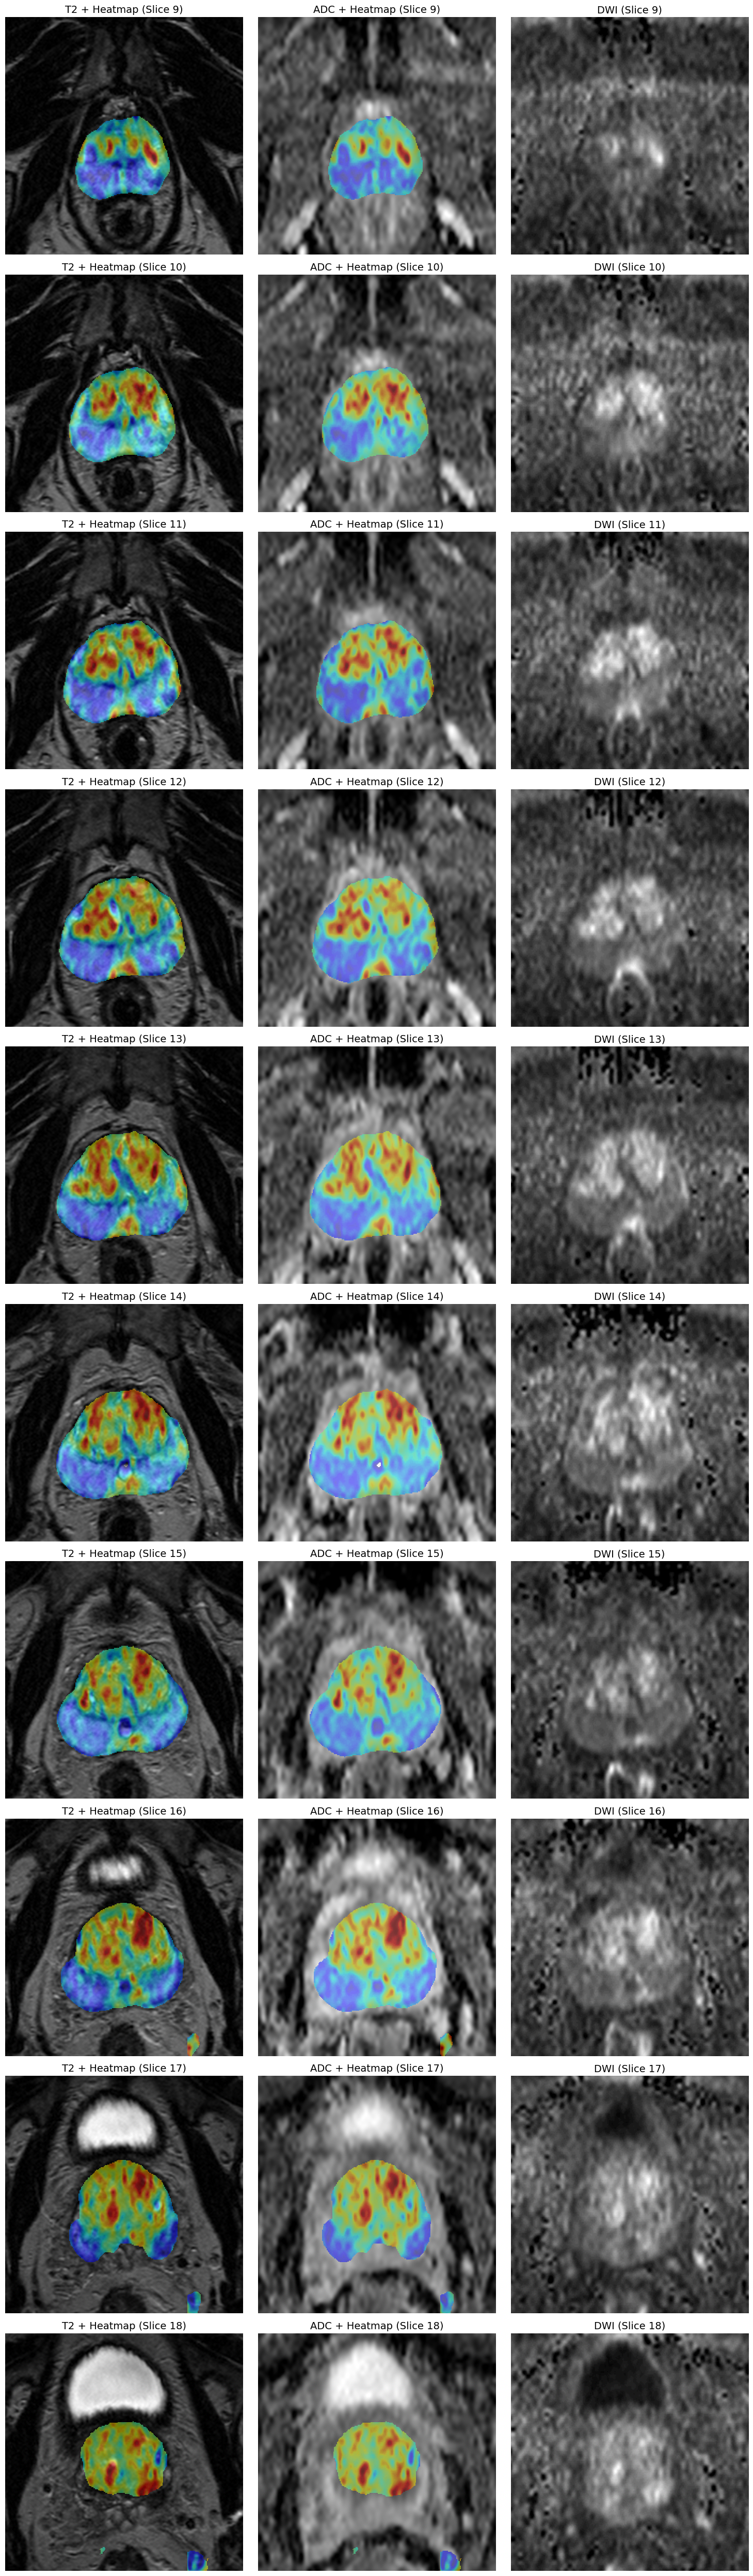

1.3.6.1.4.1.14519.5.2.1.71529026836998860968674732601284923492.nrrd


In [71]:
t2_dir_proc = (
    "/sc-projects/sc-proj-cc06-ag-ki-radiologie/TCIA_prostate/nrrd_files/processed/t2_registered"
)

id = 195


file = test_data["test"][id]["image"]

t2_proc, _ = nrrd.read(os.path.join(t2_dir_proc, file))
dwi_proc, _ = nrrd.read(test_data["test"][id]["dwi"])
adc_proc, _ = nrrd.read(test_data["test"][id]["adc"])  #
heats, _ = nrrd.read(test_data["test"][id]["heatmap"])
import matplotlib.pyplot as plt
import numpy as np

# 1. Automatically find slices where the heatmap has non-zero values
# We use a tiny threshold (0.01) instead of strict 0 to ignore floating-point noise
valid_slices = []
for z in range(heats.shape[2]):
    if np.any(heats[:, :, z] > 0.01):
        valid_slices.append(z)

num_slices = len(valid_slices)

print(f"Found {num_slices} slices with active heatmap out of {heats.shape[2]} total slices.")
print(f"Plotting slices: {valid_slices}")

# 2. Safety check in case the heatmap is completely blank
if num_slices == 0:
    print("Warning: The heatmap is entirely zero across all slices.")
else:
    # 3. Create the dynamic grid based on how many valid slices were found
    fig, axes = plt.subplots(nrows=num_slices, ncols=3, figsize=(15, 5 * num_slices))

    # If there is only exactly 1 slice with a heatmap, axes is 1D.
    # We force it to 2D so our loop doesn't break.
    if num_slices == 1:
        axes = np.expand_dims(axes, axis=0)

    # 4. Plot the columns for the filtered slices
    for i, z in enumerate(valid_slices):
        # Extract the 2D slices
        t2_slice = t2_proc[:, :, z].T
        adc_slice = adc_proc[:, :, z].T
        dwi_slice = dwi_proc[:, :, z].T
        heat_slice = heats[:, :, z].T

        # Mask the background zeroes of the heatmap so it doesn't tint the healthy tissue
        masked_heat = np.ma.masked_where(heat_slice <= 0.01, heat_slice)

        # --- Column 1: T2 + Heatmap ---
        axes[i, 0].imshow(t2_slice, cmap="gray")
        axes[i, 0].imshow(masked_heat, cmap="jet", alpha=0.5)
        axes[i, 0].set_title(f"T2 + Heatmap (Slice {z})", fontsize=14)
        axes[i, 0].axis("off")

        # --- Column 2: ADC + Heatmap ---
        axes[i, 1].imshow(adc_slice, cmap="gray")
        axes[i, 1].imshow(masked_heat, cmap="jet", alpha=0.5)
        axes[i, 1].set_title(f"ADC + Heatmap (Slice {z})", fontsize=14)
        axes[i, 1].axis("off")

        # --- Column 3: DWI (No Heatmap) ---
        axes[i, 2].imshow(dwi_slice, cmap="gray")
        axes[i, 2].set_title(f"DWI (Slice {z})", fontsize=14)
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()
print(file)

In [72]:
import shutil

in_folder = "/sc-projects/sc-proj-cc06-ag-ki-radiologie/TCIA_prostate/nrrd_files/processed"
out_folder = "/sc-projects/sc-proj-cc06-ag-ki-radiologie/TCIA_prostate/keno_files"
for i in ["t2_registered", "ADC_clipped", "DWI_registered", "smooth_prostate_mask"]:
    shutil.copy(os.path.join(in_folder, i, file), os.path.join(out_folder, i.split("_")[0], file))

### PIRADS

In [ ]:
import logging
import os
import shutil
import sys
import time
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import wandb
import yaml
from monai.utils import set_determinism

from src.data.data_loader import get_dataloader
from src.model.mil import MILModel3D
from src.train.train_pirads import val_epoch
from src.utils import setup_logging

In [ ]:
from types import SimpleNamespace

with open("config/config_pirads_test.yaml") as f:
    config = yaml.safe_load(f)


args = SimpleNamespace(**config)
print(args.data_root)

args.mode = "test"
args.project_dir = Path.cwd()
args.run_name = "test_dummy_pirads"
args.checkpoint_pirads = None
args.wandb = False
args.optim_lr = 2e-5
args.batch_size = 8
args.epochs = 1
args.project_name = "Dummy"
args.workers = 0
args.use_psa = False

In [ ]:
args.logdir = os.path.join(args.project_dir, "logs", args.run_name)
os.makedirs(args.logdir, exist_ok=True)
args.logfile = os.path.join(args.logdir, f"{args.run_name}.log")
setup_logging(args.logfile)

logging.info("Argument values:")
for k, v in vars(args).items():
    logging.info(f"{k} => {v}")
logging.info("-----------------")

args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if args.device == torch.device("cpu"):
    args.amp = False
if args.dataset_json is None:
    logging.error("Dataset JSON file not provided. Quitting.")
    sys.exit(1)
if args.checkpoint is None and args.mode == "test":
    logging.error("Model checkpoint path not provided. Quitting.")
    sys.exit(1)

mode_wandb = "online" if args.wandb and args.mode != "test" else "disabled"

config_wandb = {
    "learning_rate": args.optim_lr,
    "batch_size": args.batch_size,
    "epochs": args.epochs,
    "patch size": args.tile_size,
    "patch count": args.tile_count,
}
wandb.init(
    project=args.project_name,
    name=args.run_name,
    dir=os.path.join(args.logdir, "wandb"),
    config=config_wandb,
    mode=mode_wandb,
)

In [ ]:
if args.device == torch.device("cuda"):
    torch.backends.cudnn.benchmark = True
model = MILModel3D(num_classes=args.num_classes, mil_mode=args.mil_mode)
start_epoch = 0
best_acc = 0.0
if args.checkpoint is not None:
    checkpoint = torch.load(args.checkpoint, map_location="cpu")
    model.load_state_dict(checkpoint["state_dict"])

    if "epoch" in checkpoint:
        start_epoch = checkpoint["epoch"]
    if "best_acc" in checkpoint:
        best_acc = checkpoint["best_acc"]
    logging.info(
        "=> loaded checkpoint %s (epoch %d) (bestacc %f)",
        args.checkpoint,
        start_epoch,
        best_acc,
    )
cache_dir_ = os.path.join(args.logdir, "cache")
model.to(args.device)
params = model.parameters()

In [ ]:
valid_loader = get_dataloader(args, split=args.mode)
val_loss, val_acc, qwk = val_epoch(model, valid_loader, epoch=0, args=args)
if os.path.exists(cache_dir_):
    shutil.rmtree(cache_dir_)

qwk

In [ ]:
import logging

import numpy as np
import torch
import torch.nn as nn
from monai.metrics import Cumulative, CumulativeAverage
from sklearn.metrics import cohen_kappa_score
from tqdm import tqdm

valid_loader = get_dataloader(args, split=args.mode)

criterion = nn.CrossEntropyLoss()

run_loss = CumulativeAverage()
run_acc = CumulativeAverage()
preds_cumulative = Cumulative()
targets_cumulative = Cumulative()
targets_cumulative_bin = Cumulative()

start_time = time.time()
loss, acc = 0.0, 0.0
model.eval()
with torch.no_grad():
    for idx, batch_data in tqdm(enumerate(valid_loader)):
        data = batch_data["image"].as_subclass(torch.Tensor).to(args.device)
        target = batch_data["pirads"].as_subclass(torch.Tensor).to(args.device)
        target_bin = batch_data["label"].as_subclass(torch.Tensor).to(args.device)
        target = target.long()
        target_bin = target_bin.long()

        with torch.amp.autocast(device_type=str(args.device), enabled=args.amp):
            logits = model(data)

        data = data.to("cpu")
        target = target.to("cpu")
        logits = logits.to("cpu")
        pred = torch.argmax(logits, dim=1)
        acc = (pred == target).sum() / len(target)

        run_acc.append(acc.detach().cpu())
        preds_cumulative.extend(pred.detach().cpu())
        targets_cumulative.extend(target.detach().cpu())
        targets_cumulative_bin.extend(target_bin.detach().cpu())

        del data, target, logits
        torch.cuda.empty_cache()

    # Calculate QWK metric (Quadratic Weigted Kappa) https://en.wikipedia.org/wiki/Cohen%27s_kappa
    preds_cumulative = preds_cumulative.get_buffer().cpu().numpy()
    targets_cumulative = targets_cumulative.get_buffer().cpu().numpy()
    targets_cumulative_bin = targets_cumulative_bin.get_buffer().cpu().numpy()
preds_updated = preds_cumulative + 2

if os.path.exists(cache_dir_):
    shutil.rmtree(cache_dir_)

In [ ]:
qwk = cohen_kappa_score(targets_cumulative.astype(np.float64), preds_updated.astype(np.float64))
qwk

In [ ]:
preds_updated

In [ ]:
import pandas as pd

df = pd.DataFrame({"target": targets_cumulative, "pred": preds_updated})

# Group by class and show summary stats


conf_matrix = pd.crosstab(df["target"], df["pred"])

print(conf_matrix)

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(targets_cumulative_bin, preds_cumulative)

In [ ]:
import pandas as pd

df = pd.DataFrame({"pirads": preds_updated, "cspca": targets_cumulative_bin})
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ct = pd.crosstab(df["pirads"], df["cspca"])

# Add totals
ct_with_totals = ct.copy()
ct_with_totals["Total"] = ct_with_totals.sum(axis=1)  # row totals
ct_with_totals.loc["Total"] = ct_with_totals.sum(axis=0)  # column totals
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Base crosstab
ct = pd.crosstab(df["pirads"], df["cspca"])

# Row totals
row_totals = ct.sum(axis=1)

# Column totals
col_totals = ct.sum(axis=0)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7, 5))

# Heatmap ONLY for actual data
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)

# ---- Add row totals (right side, no color) ----
for i, val in enumerate(row_totals):
    ax.text(
        ct.shape[1] + 0.3,  # position to the right
        i + 0.5,
        str(val),
        va="center",
    )

# Label for row totals
ax.text(ct.shape[1] + 0.3, -0.3, "Total", ha="center")

# ---- Add column totals (below x-axis) ----
for j, val in enumerate(col_totals):
    ax.text(
        j + 0.5,
        ct.shape[0] + 0.3,  # position below
        str(val),
        ha="center",
    )

# Label for column totals
ax.text(-0.5, ct.shape[0] + 0.3, "Total", va="center")

# ---- Adjust limits so text is visible ----
ax.set_xlim(0, ct.shape[1] + 1)
ax.set_ylim(ct.shape[0] + 1, 0)

# Titles and labels
ax.set_title("PI-RADS vs csPCa")
ax.set_xlabel("csPCa")
ax.set_ylabel("PI-RADS")

plt.tight_layout()
plt.show()

In [ ]:
pirads_pred = [1.0 if i >= 3 else 0.0 for i in preds_updated]
pirads_pred
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

pred_cat = np.array(pirads_pred)
target_list = targets_cumulative_bin
# Basic metrics
acc = accuracy_score(target_list, pred_cat)
precision = precision_score(target_list, pred_cat)
recall = recall_score(target_list, pred_cat)
f1 = f1_score(target_list, pred_cat)
balanced_acc = balanced_accuracy_score(target_list, pred_cat)
# Confusion matrix
cm = confusion_matrix(target_list, pred_cat)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall (Sensitivity):", recall)
print("F1 Score:", f1)
print("Balanced Accuracy:", balanced_acc)

print("\nConfusion Matrix:")
print(cm)

print("\nDetailed Report:")
print(classification_report(target_list, pred_cat))

### Ordinal Loss

In [2]:
import json
import logging
import os
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import torch
import wandb
import yaml
from monai.utils import set_determinism
from sklearn.preprocessing import StandardScaler

from src.data.data_loader import get_dataloader
from src.model.mil import MILModel3D
from src.train.train_pirads import val_epoch
from src.utils import setup_logging

In [3]:
from types import SimpleNamespace

with open("config/config_pirads_train.yaml") as f:
    config = yaml.safe_load(f)


args = SimpleNamespace(**config)
print(args.data_root)

args.mode = "rain"
args.project_dir = Path.cwd()
args.run_name = "test_dummy_pirads"
args.checkpoint = None
args.wandb = False
args.optim_lr = 2e-5
args.batch_size = 8
args.epochs = 1
args.project_name = "Dummy"
args.workers = 0
args.use_psa = False

/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/t2_registered


In [4]:
args.logdir = os.path.join(args.project_dir, "logs", args.run_name)
os.makedirs(args.logdir, exist_ok=True)
args.logfile = os.path.join(args.logdir, f"{args.run_name}.log")
setup_logging(args.logfile)

logging.info("Argument values:")
for k, v in vars(args).items():
    logging.info(f"{k} => {v}")
logging.info("-----------------")

args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if args.device == torch.device("cpu"):
    args.amp = False
if args.dataset_json is None:
    logging.error("Dataset JSON file not provided. Quitting.")
    sys.exit(1)
if args.checkpoint is None and args.mode == "test":
    logging.error("Model checkpoint path not provided. Quitting.")
    sys.exit(1)

mode_wandb = "online" if args.wandb and args.mode != "test" else "disabled"

config_wandb = {
    "learning_rate": args.optim_lr,
    "batch_size": args.batch_size,
    "epochs": args.epochs,
    "patch size": args.tile_size,
    "patch count": args.tile_count,
}
wandb.init(
    project=args.project_name,
    name=args.run_name,
    dir=os.path.join(args.logdir, "wandb"),
    config=config_wandb,
    mode=mode_wandb,
)

In [5]:
if args.device == torch.device("cuda"):
    torch.backends.cudnn.benchmark = True

model = MILModel3D(num_classes=args.num_classes, mil_mode=args.mil_mode)
start_epoch = 0
best_acc = 0.0
if args.checkpoint is not None:
    checkpoint = torch.load(args.checkpoint, map_location="cpu")
    model.load_state_dict(checkpoint["state_dict"])

    if "epoch" in checkpoint:
        start_epoch = checkpoint["epoch"]
    if "best_acc" in checkpoint:
        best_acc = checkpoint["best_acc"]
    logging.info(
        "=> loaded checkpoint %s (epoch %d) (bestacc %f)",
        args.checkpoint,
        start_epoch,
        best_acc,
    )
cache_dir_ = os.path.join(args.logdir, "cache")
model.to(args.device)
params = model.parameters()

scaler = StandardScaler()
with open(os.path.join(args.project_dir, "dataset", "PICAI_cspca_updated_with_psa.json")) as f:
    dataset_json = json.load(f)
train_clinical = [i["psa"] for i in dataset_json["train"]]
_ = scaler.fit_transform(train_clinical)
args.psa_mean = scaler.mean_.tolist()
args.psa_std = scaler.scale_.tolist()

In [6]:
train_loader = get_dataloader(args, split="train")
valid_loader = get_dataloader(args, split="test")
logging.info(f"Dataset training: {len(train_loader.dataset)}, test: {len(valid_loader.dataset)}")

if args.mil_mode in ["att_trans", "att_trans_pyramid"]:
    params = [
        {
            "params": list(model.attention.parameters())
            + list(model.myfc.parameters())
            + list(model.net.parameters())
            # + list(model.feature_proj.parameters()),
        },
        {"params": list(model.transformer.parameters()), "lr": 6e-5, "weight_decay": 0.1},
    ]

optimizer = torch.optim.AdamW(params, lr=args.optim_lr, weight_decay=args.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs, eta_min=0)
scaler = torch.amp.GradScaler(device=str(args.device), enabled=args.amp)

In [7]:
import logging
import time

import numpy as np
import torch
import torch.nn as nn
from monai.metrics import Cumulative, CumulativeAverage
from sklearn.metrics import cohen_kappa_score

model.train()
criterion = nn.BCEWithLogitsLoss()
att_criterion = nn.CosineSimilarity(dim=1, eps=1e-6)

run_att_loss = CumulativeAverage()
run_loss = CumulativeAverage()
run_acc = CumulativeAverage()
batch_norm = CumulativeAverage()

start_time = time.time()
loss, acc = 0.0, 0.0

for idx, batch_data in enumerate(train_loader):
    eps = 1e-8
    data = batch_data["image"].as_subclass(torch.Tensor)
    target = batch_data["label"].as_subclass(torch.Tensor).to(args.device)

    shuffled_images = data.to(args.device)

    optimizer.zero_grad(set_to_none=True)
    with torch.amp.autocast(device_type=str(args.device), enabled=args.amp):
        # Classification Loss
        logits_attn = model(shuffled_images, no_head=True)
        x = logits_attn.to(torch.float32)
        # x = x.permute(1, 0, 2)
        # x = model.feature_proj(x)
        x = model.transformer(x)
        # x = x.permute(1, 0, 2)
        a = model.attention(x)
        a = torch.softmax(a, dim=1)
        x = torch.sum(x * a, dim=1)
        logits = model.myfc(x)
        class_loss = criterion(logits, target)
        # Attention Loss

        loss = class_loss
        attn_loss = torch.tensor(0.0)

    break

In [10]:
class_loss

tensor(0.8187, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [12]:
logits

tensor([[-0.2939,  0.1267,  0.6562],
        [-0.4866,  0.2090,  0.6338],
        [-0.5596,  0.3350,  0.7041],
        [-0.7207,  0.0269,  0.5449],
        [-0.5552,  0.3318,  0.5625],
        [-0.4041,  0.1666,  0.6338],
        [-0.5308,  0.1079,  0.5000],
        [-0.5049,  0.1185,  0.6562]], device='cuda:0', dtype=torch.float16,
       grad_fn=<AddmmBackward0>)

In [15]:
logits.shape

torch.Size([8, 3])

In [16]:
target

tensor([[1., 1., 1.],
        [0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 1.],
        [1., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 1., 0.]], device='cuda:0')

In [11]:
pred = torch.argmax(logits, dim=1)
pred

tensor([2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')

In [18]:
probs = torch.sigmoid(logits)
binary_preds = (probs > 0.5).int()

In [19]:
binary_preds

tensor([[0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1]], device='cuda:0', dtype=torch.int32)

In [24]:
pred_pirads = binary_preds.sum(dim=1)
pred_pirads

tensor([2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')

In [25]:
binary_preds

tensor([[0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1],
        [0, 1, 1]], device='cuda:0', dtype=torch.int32)

In [30]:
(pred_pirads == target.sum(dim=1)).sum() / len(pred_pirads)

tensor(0.2500, device='cuda:0')

In [32]:
len(pred_pirads)

8

In [23]:
binary_preds == target

tensor([[False,  True,  True],
        [ True, False, False],
        [ True, False, False],
        [False,  True,  True],
        [False,  True, False],
        [False, False, False],
        [False, False, False],
        [False,  True, False]], device='cuda:0')

### Run Inference Amend

In [1]:
import argparse
import json
import logging
import os
from pathlib import Path

import streamlit as st
import torch
import yaml
from monai.data import Dataset

from src.data.data_loader import data_transform, list_data_collate
from src.model.cspca_model import CSPCAModel
from src.model.mil import MILModel3D
from src.preprocessing.clip_intensity import clip_adc
from src.preprocessing.generate_heatmap import get_heatmap
from src.preprocessing.prostate_mask import get_segmask
from src.preprocessing.register_and_crop import register_files
from src.utils import get_parent_image, get_patch_coordinate, setup_logging, get_prostate_volume
from sklearn.preprocessing import StandardScaler

from argparse import Namespace
from collections.abc import Callable

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_prep



In [2]:
from argparse import Namespace

args = Namespace(
    config="config.yaml",
    json_path="/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/psa_val.json", 
    t2_dir="/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/t2",
    dwi_dir="/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/dwi",
    adc_dir="/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/adc",
    seg_dir="/path/to/seg",
    output_dir="/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/processed",
    margin=0.2,
    num_classes=4,
    mil_mode="att_trans",
    use_heatmap=True,
    use_psa=True,
    tile_size=48,
    tile_count=40,
    depth=3,
    project_dir="/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate",
)

In [3]:
FUNCTIONS: dict[str, Callable[[Namespace], Namespace]] = {
    "register_and_crop": register_files,
    "clip_adc": clip_adc,
    "get_segmentation_mask": get_segmask,
    "get_heatmap": get_heatmap,
}
args.logfile = os.path.join(args.output_dir, "inference.log")
setup_logging(args.logfile)
logging.info("Starting preprocessing")
steps = ["register_and_crop", "get_segmentation_mask", "clip_adc", "get_heatmap"]
for step in steps:
    #if step == 'get_segmentation_mask':
    #    args.seg_dir = os.path.join(args.output_dir, "prostate_mask")
    #    continue
    func = FUNCTIONS[step]
    
    args = func(args)

logging.info("Preprocessing completed.")
args.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


100%|██████████| 1/1 [00:02<00:00,  2.04s/it]
You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


  0%|          | 0/1 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
for key, value in vars(args).items():
    print(f"{key}: {value}")

config: config.yaml
json_path: /sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/psa_val.json
t2_dir: /sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/processed/t2_registered
dwi_dir: /sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/processed/DWI_registered
adc_dir: /sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/processed/ADC_clipped
seg_dir: /sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/processed/prostate_mask
output_dir: /sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate/datatemp/processed
margin: 0.2
num_classes: 4
mil_mode: att_trans
use_heatmap: True
use_psa: True
tile_size: 48
tile_count: 40
depth: 3
project_dir: /sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate
logfile: /sc-scrat

In [ ]:
scaler = StandardScaler()
with open(os.path.join(args.project_dir, "dataset", "PICAI_cspca_updated_with_psa.json")) as f:
    dataset_json = json.load(f)
train_clinical = [i["psa"] for i in dataset_json["train"]]
_ = scaler.fit_transform(train_clinical)
args.psa_mean = scaler.mean_.tolist()
args.psa_std = scaler.scale_.tolist()

In [ ]:
transform = data_transform(args, split='test')
files = os.listdir(args.t2_dir)
args.data_list = []
with open(args.json_path, 'r') as f:
    psa_data = json.load(f)

In [ ]:
for file in files:
    temp = {}
    temp["image"] = os.path.join(args.t2_dir, file)
    temp["dwi"] = os.path.join(args.dwi_dir, file)
    temp["adc"] = os.path.join(args.adc_dir, file)
    temp["heatmap"] = os.path.join(args.heatmapdir, file)
    temp["mask"] = os.path.join(args.seg_dir, file)
    temp["label"] = 0  # dummy label
    temp["smooth_mask"] = os.path.join(args.smooth_seg_dir, file)
    prostate_vol = get_prostate_volume(temp["mask"])
    temp["psa"] = [psa_data[file.split('.nrrd')[0]] , prostate_vol]
    args.data_list.append(temp)

In [ ]:

dataset = Dataset(data=args.data_list, transform=transform)
loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    multiprocessing_context=None,
    sampler=None,
    collate_fn=list_data_collate,
)

### Preprocess

In [4]:
import argparse
import logging
import os
from argparse import Namespace
from collections.abc import Callable
from pathlib import Path

import yaml

from src.preprocessing.clip_intensity import clip_adc
from src.preprocessing.generate_heatmap import get_heatmap
from src.preprocessing.prostate_mask import get_segmask
from src.preprocessing.register_and_crop import register_files
from src.utils import setup_logging

In [8]:
from argparse import Namespace

args = Namespace(
    t2_dir='/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/t2_registered',
    dwi_dir='/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/DWI_registered',
    adc_dir='/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/ADC_registered',
    seg_dir='/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/cropped_prostate_mask',
    output_dir='/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed'
)

In [9]:
args.steps = [ "clip_adc", "get_heatmap"]
args.project_dir = '/sc-scratch/sc-scratch-cc06-ag-ki-radiologie/prostate_foundation/WSAttention-Prostate'

args = clip_adc(args)


  2%|▏         | 134/6733 [00:10<09:17, 11.83it/s]

100%|██████████| 6733/6733 [09:23<00:00, 11.95it/s]


In [10]:
args.adc_dir

'/sc-projects/sc-proj-cc06-ag-ki-radiologie/prostate-foundation/processed/ADC_clipped'

In [12]:
args = get_heatmap(args)

100%|██████████| 6733/6733 [18:50<00:00,  5.95it/s]
